<a href="https://colab.research.google.com/github/viktoryamargaryan/Real-Estate-mini-project/blob/main/Mini_Project_Viktorya_Margaryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project: Data Collection and Analysis**



# *Introduction*

---

In this mini-project, I focus on collecting and analyzing real-estate data, specifically apartments that are currently listed for sale. The goal of the project is to demonstrate the complete data analysis workflow—starting from web scraping and ending with exploratory data analysis (EDA).

For data collection, I selected the Armenian real estate website [real-estate.am](https://www.real-estate.am/ctg/gnel-bnakaran), which provides up-to-date listings of apartments available for sale in different districts of Yerevan.

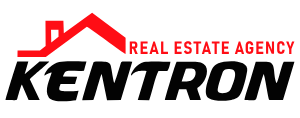

# *Web scraping*

---

In this part of the project, I collect apartment listings from the website real-estate.am using Python. For scraping the data, I use the libraries Requests (to download the HTML pages) and BeautifulSoup (to parse and extract information from the HTML structure). The code automatically goes through several pages, finds each apartment card, and collects details such as the apartment `ID`, `link`, `location`, `price`, `number of rooms`, `area`, and `floor`. The scraped information is cleaned and organized into a structured list. Finally, I save all extracted data into a CSV file called `real-estate.csv`, which will be used later for data cleaning, preprocessing, and analysis․



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import csv
import re

# Base URL for scraping
BASE_URL = "https://www.real-estate.am"

# Set headers
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/115.0.0.0 Safari/537.36"
}

def scrape_listings(url):
    print(f"Fetching: {url}")
    response = requests.get(url, headers=HEADERS)

    if response.status_code != 200:
        print(f"Failed to get page: HTTP {response.status_code}")
        return []

    # Parse HTML content
    soup = BeautifulSoup(response.text, "html.parser")

    # Target the main listing container on the results page
    listing_containers = soup.find_all("a", class_=re.compile(r'flex flex-col bg-card rounded-2xl w-full relative'))

    listings = []
    for container in listing_containers:

        # Link
        link = container["href"] if "href" in container.attrs else None
        if link and link.startswith("/"):
            link = BASE_URL + link

       # ID Extraction
        id_tag = container.find("p", class_="p-[4px_12px] w-max bg-card rounded-lg")
        listing_id = id_tag.text.strip().replace('ID ', '') if id_tag and 'ID' in id_tag.text else "No ID"
        ID = listing_id

        # Location
        location_tag = container.find("p", class_="text-sm text-muted-foreground")
        location = location_tag.text.strip() if location_tag else "No location"

        # Price
        price_tag = container.find("p", class_="text-xl font-bold")
        price = price_tag.text.strip() if price_tag else "No price"

        # --- Property Attributes (Rooms, Area, Floor, etc.) ---

        bedrooms, area, floor = None, None, None

        # Assuming the property details are grouped together (Guess for the class)
        details_list_wrapper = container.find('div', class_=re.compile(r'flex gap-2 my-2 flex-wrap'))

        # --- Helper function definition ---
        def extract_detail(detail_element):
            """
            Extracts text from an element, skipping the icon/SVG and cleans the result.
            """
            if not detail_element:
                return None

            # Get all stripped strings (text nodes) inside the div
            parts = [s.strip() for s in detail_element.stripped_strings if s.strip()]
            return ' '.join(parts)


        if details_list_wrapper:
            # Individual Detail Item (Simplified class)
            details = details_list_wrapper.find_all('div', class_=re.compile(r'flex gap-1 items-center font-semibold'))

            # Check the number of items and extract them sequentially
            if len(details) >= 3:

                # 1. Bedrooms / Rooms
                bedrooms = extract_detail(details[0])

                # 2. Area
                area = extract_detail(details[1])

                # 3. Floor
                # Extract the raw text first
                floor = extract_detail(details[2])


        # Add to our list
        listings.append({
            "Apartment ID": ID,
            "Link": link,
            "Location": location,
            "Price": price,
            "Bedrooms": bedrooms,
            "Area": area,
            "Floor": floor
        })

    return listings

# --- Main Functions ---

def save_to_csv(listings, filename="real-estate.csv"):
    """Save the scraped data to a CSV file."""
    keys = listings[0].keys() if listings else [
        "Apartment ID", "Link", "Location", "Price",
        "Bedrooms", "Area", "Floor"
    ]
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(listings)
    print(f"Data saved to {filename}.")


def main():
    print("Scraping started ...")

    all_listings = []

    # Scrape four pages
    for page in range(1, 5):
        url = f"{BASE_URL}/ctg/gnel-bnakaran?size=72&page={page}"

        page_listings = scrape_listings(url)
        all_listings.extend(page_listings)

        # Wait between requests
        time.sleep(2)

    print(f"\nFound a total of {len(all_listings)} listings across all pages.")

    if all_listings:
        # Display the first 5 entries
        print("\nFirst 5 entries:")
        print(pd.DataFrame(all_listings[:5]))

        save_to_csv(all_listings)

    print("\nDone.")

if __name__ == "__main__":
    main()

Scraping started ...
Fetching: https://www.real-estate.am/ctg/gnel-bnakaran?size=72&page=1
Fetching: https://www.real-estate.am/ctg/gnel-bnakaran?size=72&page=2
Fetching: https://www.real-estate.am/ctg/gnel-bnakaran?size=72&page=3
Fetching: https://www.real-estate.am/ctg/gnel-bnakaran?size=72&page=4

Found a total of 288 listings across all pages.

First 5 entries:
  Apartment ID                                               Link  \
0       415153  https://www.real-estate.am/prp/bnakaran/gnel/y...   
1       410162  https://www.real-estate.am/prp/bnakaran/gnel/y...   
2       416802  https://www.real-estate.am/prp/bnakaran/gnel/y...   
3       416840  https://www.real-estate.am/prp/bnakaran/gnel/y...   
4       413325  https://www.real-estate.am/prp/bnakaran/gnel/y...   

                                      Location      Price Bedrooms  \
0  Պարույր Սևակի փողոց, Քանաքեռ-Զեյթուն, Երևան  $ 130,000        3   
1              Անտառային փողոց, Կենտրոն, Երևան  $ 360,000        3   
2      

In [ ]:
df = pd.read_csv('real-estate.csv')

In [ ]:
df

,Apartment ID,Link,Location,Price,Bedrooms,Area,Floor
0,415153,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Պարույր Սևակի փողոց, Քանաքեռ-Զեյթուն, Երևան","$ 130,000",3,86 ք.մ.,8 / 18
1,410162,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Անտառային փողոց, Կենտրոն, Երևան","$ 360,000",3,130 ք.մ.,3 / 5
2,416802,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Ադոնց փողոց, Արաբկիր, Երևան","$ 175,000",4,109.5 ք.մ.,16 / 16
3,416840,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Ղափանցյան փողոց, Արաբկիր, Երևան","$ 110,000",2,53 ք.մ.,12 / 18
4,413325,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Սասնա Ծռերի փողոց, Դավթաշեն, Երևան","$ 153,000",2,49 ք.մ.,11 / 18
...,...,...,...,...,...,...,...
283,402420,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Արամ Խաչատրյան փողոց, Արաբկիր, Երևան","$ 425,000",3,116 ք.մ.,3 / 16
284,403156,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Փարպեցու փողոց, Կենտրոն, Երևան","$ 490,000",2,61 ք.մ.,1 / 3
285,403285,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Արգիշտի փողոց, Կենտրոն, Երևան","$ 107,000",1,35 ք.մ.,2 / 14
286,403421,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Վաղարշյան փողոց, Արաբկիր, Երևան","$ 150,000",3,68 ք.մ.,5 / 9


# *Data Cleaning*
---

In the data cleaning stage, I load the scraped dataset from real-estate.csv and prepare it for analysis. I use the libraries `Pandas` and `NumPy`, which help clean missing values and convert text into numbers. First, I remove rows where important information such as the price or location is missing, because these fields are necessary for analysis. Then, I clean the numeric columns: the price is stripped from symbols and converted into an integer, the area is extracted from text and converted into a numeric value, and the number of bedrooms is cleaned from extra characters. I also fix the floor information by splitting it into two separate columns: the current floor and the total number of floors. After all the transformations, I save the cleaned dataset into a new file named `cleaned_real_estate.csv`, which will be used for further preprocessing and analysis.


In [ ]:
import numpy as np

# --- File Configuration ---
INPUT_FILE = "real-estate.csv"
OUTPUT_FILE = "cleaned_real_estate.csv"

def clean_data(df):
    """
    Performs all necessary cleaning and transformation operations on the DataFrame.
    """
    print("Starting data cleaning process...")

    # Handling Missing/Inconsistent Data (Removing Rows)
    initial_rows = len(df)
    df.replace(['No price', 'No location', 'No ID', 'None'], np.nan, inplace=True)
    df.dropna(subset=['Price', 'Location'], inplace=True)

    cleaned_rows = len(df)
    print(f"Initial number of rows: {initial_rows}")
    print(f"Rows removed due to missing Price/Location: {initial_rows - cleaned_rows}")
    print(f"Remaining number of rows: {cleaned_rows}")


    # Part 2: Cleaning and Converting Numeric Fields

    # 1.Price
    df['Price'] = df['Price'].astype(str).str.replace(r'[$,\s]', '', regex=True)
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce').astype('Int64')

    # 2. Area
    df['Area'] = df['Area'].astype(str)
    df['Area'] = df['Area'].str.replace('p.u.', '', regex=False)
    df['Area'] = df['Area'].str.replace('ք․մ․', '', regex=False)
    df['Area'] = df['Area'].str.replace('Քառ․ մ․', '', regex=False)
    df['Area'] = df['Area'].str.strip()
    df['Area'] = df['Area'].str.extract(r'(\d+\.?\d*)', expand=False)
    df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

    # 3. Bedrooms
    df['Bedrooms'] = df['Bedrooms'].astype(str).str.replace(r'[^\d]', '', regex=True)
    df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce').astype('Int64')

    print("Price, Area, and Bedrooms cleaned and converted to numeric types.")


    # Part 3: Splitting the Floor Column

    floor_split = df['Floor'].astype(str).str.split('/', expand=True)

    # 1. Floor_Level: The current floor (first part)
    df['Floor_Level'] = pd.to_numeric(floor_split[0], errors='coerce').astype('Int64')

    # 2. Total_Floors: The total number of floors (second part)
    df['Total_Floors'] = pd.to_numeric(floor_split[1], errors='coerce').astype('Int64')

    # If Total_Floor number is missing fill it with Floor_Level value.
    df['Total_Floors'] = df['Total_Floors'].fillna(df['Floor_Level'])

    # Droping the original 'Floor' column...
    df.drop('Floor', axis=1, inplace=True)

    print("'Floor' column successfully split into 'Floor_Level' and 'Total_Floors'.")

    return df

def main():
    try:
        df = pd.read_csv(INPUT_FILE, dtype=str)
    except FileNotFoundError:
        print(f"Error: The file '{INPUT_FILE}' was not found.")
        return

    # Calling the cleaning function
    cleaned_df = clean_data(df)

    # Save the cleaned data to a new file
    cleaned_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f"\nCleaning successfully completed.")
    print(f"Cleaned data saved to '{OUTPUT_FILE}'.")
    print("\nFirst 5 cleaned rows:")
    print(cleaned_df.head())

if __name__ == "__main__":
    main()

Starting data cleaning process...
Initial number of rows: 288
Rows removed due to missing Price/Location: 4
Remaining number of rows: 284
Price, Area, and Bedrooms cleaned and converted to numeric types.
'Floor' column successfully split into 'Floor_Level' and 'Total_Floors'.

Cleaning successfully completed.
Cleaned data saved to 'cleaned_real_estate.csv'.

First 5 cleaned rows:
  Apartment ID                                               Link  \
0       415153  https://www.real-estate.am/prp/bnakaran/gnel/y...   
1       410162  https://www.real-estate.am/prp/bnakaran/gnel/y...   
2       416802  https://www.real-estate.am/prp/bnakaran/gnel/y...   
3       416840  https://www.real-estate.am/prp/bnakaran/gnel/y...   
4       413325  https://www.real-estate.am/prp/bnakaran/gnel/y...   

                                      Location   Price  Bedrooms   Area  \
0  Պարույր Սևակի փողոց, Քանաքեռ-Զեյթուն, Երևան  130000         3   86.0   
1              Անտառային փողոց, Կենտրոն, Երևան  3600

In [ ]:
cleaneddf = pd.read_csv('cleaned_real_estate.csv')
cleaneddf

,Apartment ID,Link,Location,Price,Bedrooms,Area,Floor_Level,Total_Floors
0,415153,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Պարույր Սևակի փողոց, Քանաքեռ-Զեյթուն, Երևան",130000,3,86.0,8,18
1,410162,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Անտառային փողոց, Կենտրոն, Երևան",360000,3,130.0,3,5
2,416802,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Ադոնց փողոց, Արաբկիր, Երևան",175000,4,109.5,16,16
3,416840,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Ղափանցյան փողոց, Արաբկիր, Երևան",110000,2,53.0,12,18
4,413325,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Սասնա Ծռերի փողոց, Դավթաշեն, Երևան",153000,2,49.0,11,18
...,...,...,...,...,...,...,...,...
279,402420,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Արամ Խաչատրյան փողոց, Արաբկիր, Երևան",425000,3,116.0,3,16
280,403156,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Փարպեցու փողոց, Կենտրոն, Երևան",490000,2,61.0,1,3
281,403285,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Արգիշտի փողոց, Կենտրոն, Երևան",107000,1,35.0,2,14
282,403421,https://www.real-estate.am/prp/bnakaran/gnel/y...,"Վաղարշյան փողոց, Արաբկիր, Երևան",150000,3,68.0,5,9


# *Data Preprocessing*

---
Here, I prepared the cleaned dataset for analysis and modeling. With the help of scikit-learn, I performed feature engineering, encoded categorical data, and scaled numerical values. I created an additional feature called `price per square meter` and filled any missing numeric values with their column averages. Then I encoded the location column into numbers and standardized the main numeric features using `StandardScaler`. These steps make the dataset ready for further statistical analysis or machine-learning models. The final processed dataset was saved as `preprocessed_real_estate.csv`.


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Configuration ---
INPUT_FILE = "cleaned_real_estate.csv"
OUTPUT_FILE = "preprocessed_real_estate.csv"

def preprocess_data(df):
    """
    Performs feature engineering, scaling, and encoding.
    """
    print("Starting Data Preprocessing (Feature Engineering & Scaling)...")


    # 1. Feature Engineering

    # Calculate Price Per Area (Standardized Metric)
    df['Price_per_sqm'] = df['Price'] / df['Area']
    df['Price_per_sqm'] = df['Price_per_sqm'].replace([np.inf, -np.inf], np.nan)

    for col in ['Price', 'Area', 'Floor_Level', 'Total_Floors', 'Bedrooms', 'Price_per_sqm']:
        if col in df.columns and df[col].dtype in ['int64', 'float64', 'Int64']:
            df[col]= df[col].fillna(df[col].mean())

    print("Price_per_sqm feature created.")
    print("All NaN values in numeric columns filled with the mean.")


    # 2. Data Encoding (Categorical to Numeric)

    le = LabelEncoder()

    # Creating a new column with the encoded integer value
    df['Location_Encoded'] = le.fit_transform(df['Location'])

    print("Location column encoded to 'Location_Encoded'.")



    # 3. Data Transformation (Scaling)

    # Define features to scale (high variance features)
    features_to_scale = ['Price', 'Area', 'Price_per_sqm']

    # Initialize the Scaler
    scaler = StandardScaler()

    # Apply standardization (Z-score scaling)
    df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

    print("Price, Area, and Price_per_sqm columns standardized.")

    # Clean up the final columns for the output CSV
    final_columns = [
        "Apartment ID", "Price", "Area", "Bedrooms",
        "Floor_Level", "Total_Floors", "Location_Encoded",
        "Price_per_sqm"
    ]


    return df[final_columns]

def main():
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"Error: The file '{INPUT_FILE}' was not found.")
        return

    # Run the preprocessing
    preprocessed_df = preprocess_data(df)

    # Save the final preprocessed data
    preprocessed_df.to_csv(OUTPUT_FILE, index=False)

    print(f"\nPreprocessing successfully completed.")
    print(f"Preprocessed data saved to '{OUTPUT_FILE}'.")
    print("\nFirst 5 rows of the preprocessed data:")
    print(preprocessed_df.head())

if __name__ == "__main__":
    main()

Starting Data Preprocessing (Feature Engineering & Scaling)...
Price_per_sqm feature created.
All NaN values in numeric columns filled with the mean.
Location column encoded to 'Location_Encoded'.
Price, Area, and Price_per_sqm columns standardized.

Preprocessing successfully completed.
Preprocessed data saved to 'preprocessed_real_estate.csv'.

First 5 rows of the preprocessed data:
   Apartment ID     Price      Area  Bedrooms  Floor_Level  Total_Floors  \
0        415153 -0.750129 -0.384047         3            8            18   
1        410162  0.275834  0.658298         3            3             5   
2        416802 -0.549398  0.172660         4           16            16   
3        416840 -0.839344 -1.165806         2           12            18   
4        413325 -0.647533 -1.260564         2           11            18   

   Location_Encoded  Price_per_sqm  
0                86      -1.005934  
1                11      -0.075939  
2                 2      -0.941934  
3      

In [ ]:
prep_df = pd.read_csv('preprocessed_real_estate.csv')
prep_df

,Apartment ID,Price,Area,Bedrooms,Floor_Level,Total_Floors,Location_Encoded,Price_per_sqm
0,415153,-0.750129,-0.384047,3,8,18,86,-1.005934
1,410162,0.275834,0.658298,3,3,5,11,-0.075939
2,416802,-0.549398,0.172660,4,16,16,2,-0.941934
3,416840,-0.839344,-1.165806,2,12,18,65,-0.588972
4,413325,-0.647533,-1.260564,2,11,18,91,0.185265
...,...,...,...,...,...,...,...,...
279,402420,0.565780,0.326643,3,3,16,13,0.585589
280,403156,0.855726,-0.976288,2,1,3,102,3.816452
281,403285,-0.852726,-1.592219,1,2,14,15,0.136972
282,403421,-0.660915,-0.810461,3,5,9,98,-0.492534


# *Data Analysis*

---
Here, I performed exploratory data analysis on the cleaned real estate dataset to understand property prices and features. Using `pandas`, I calculated a new feature called price per square meter and summarized key statistics for price, area, bedrooms, and floor level. I examined distributions with `matplotlib` and `seaborn` through histograms and box plots, and explored correlations between numerical features using heatmaps. I also conducted a hypothesis test (Welch’s T-test) with `scipy.stats `to check if high-rise and low-rise buildings differ significantly in price per square meter.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

# Set the style for the graphics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- Configuration ---
CLEANED_INPUT_FILE = "cleaned_real_estate.csv"

# Loading the cleaned data for meaningful analysis
try:
    df_clean = pd.read_csv(CLEANED_INPUT_FILE)
    print(f"Data loaded successfully from '{CLEANED_INPUT_FILE}'.")

    # Re-create Price_per_sqm needed for comparison plots and hypothesis testing
    df_clean['Price_per_sqm'] = df_clean['Price'] / df_clean['Area']

except FileNotFoundError:
    print(f"Error: The file '{CLEANED_INPUT_FILE}' was not found. Ensure it's uploaded to Colab.")

Data loaded successfully from 'cleaned_real_estate.csv'.


## Descriptive Statistics

Summary Statistics (Units: USD, Sq. Meters):
             count       mean        std      min        25%        50%  \
Price        284.0  298163.73  224575.36  71000.0  169750.00  237500.00   
Area         284.0     102.21      42.29     35.0      74.00      93.98   
Bedrooms     284.0       3.07       0.83      1.0       2.75       3.00   
Floor_Level  284.0       6.78       4.47      1.0       3.00       5.00   

                  75%        max     median  
Price        350000.0  1500000.0  237500.00  
Area            118.5      312.0      93.98  
Bedrooms          4.0        7.0       3.00  
Floor_Level      10.0       20.0       5.00  


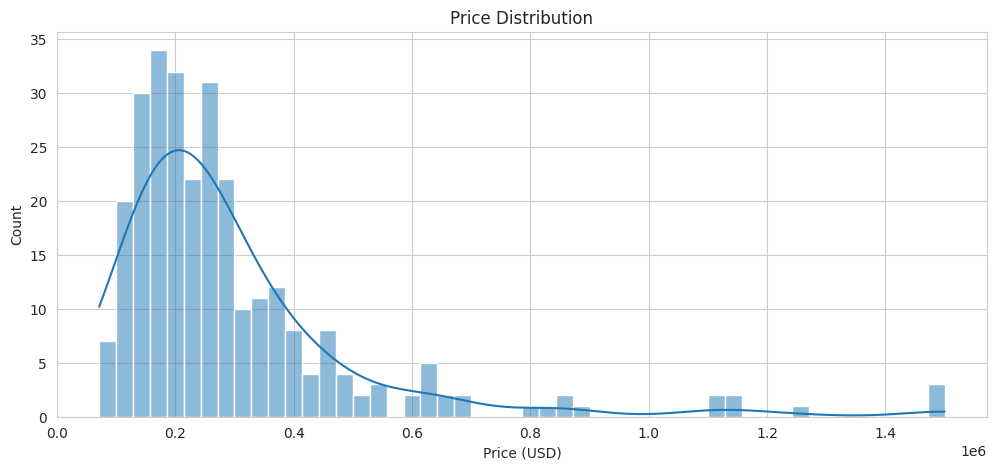

Price Skewness: 2.92


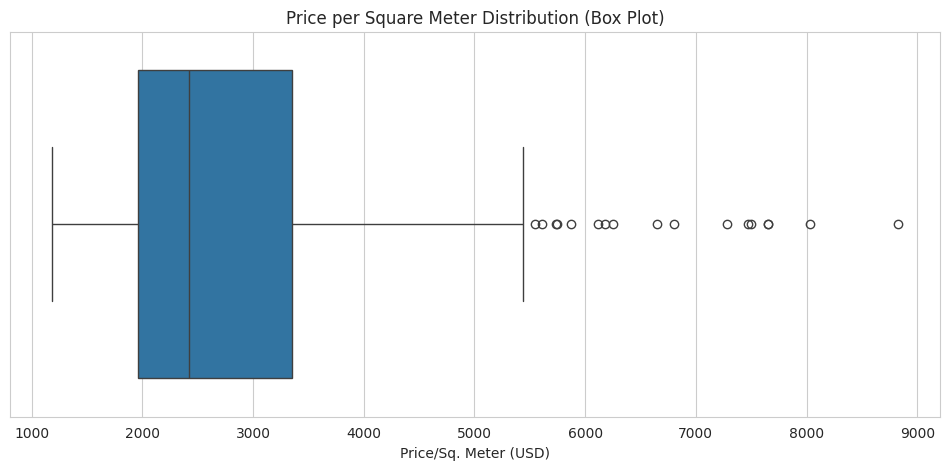

In [ ]:
# Compute summary statistics (mean, std, min, max, quartiles)
summary_stats = df_clean[['Price', 'Area', 'Bedrooms', 'Floor_Level']].describe().transpose()
summary_stats['median'] = df_clean[['Price', 'Area', 'Bedrooms', 'Floor_Level']].median()

print("Summary Statistics (Units: USD, Sq. Meters):")
print(summary_stats.round(2))


# Price Distribution (Histogram)
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.show()

# Calculate Skewness
print(f"Price Skewness: {df_clean['Price'].skew():.2f}")

# Price_per_sqm Distribution (Box Plot)
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_clean['Price_per_sqm'])
plt.title('Price per Square Meter Distribution (Box Plot)')
plt.xlabel('Price/Sq. Meter (USD)')
plt.show()

# Correlation Analysis

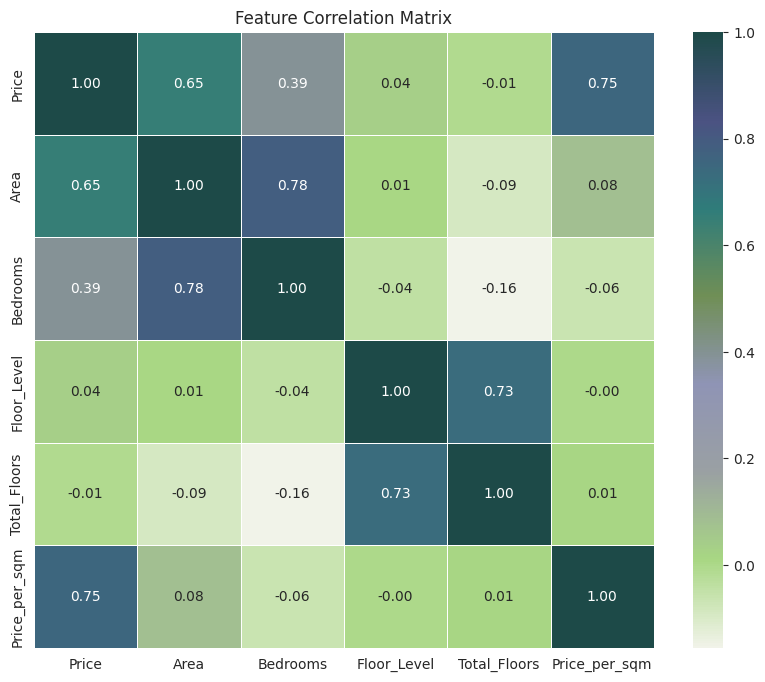

In [ ]:
# Select numerical columns for correlation
numerical_cols = ['Price', 'Area', 'Bedrooms', 'Floor_Level', 'Total_Floors', 'Price_per_sqm']

# Calculate the correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
pastel_green = LinearSegmentedColormap.from_list(
    "pastel_green",
    ['#F1F3E9', '#A8D783', '#9AA0A3', '#8F94B5', '#708F56', '#2F7C7A', '#4B5282', '#1D4A48']  # very soft green tones
)
sns.heatmap(correlation_matrix, annot=True, cmap=pastel_green, fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Hypothesis Testing and Visual Validation

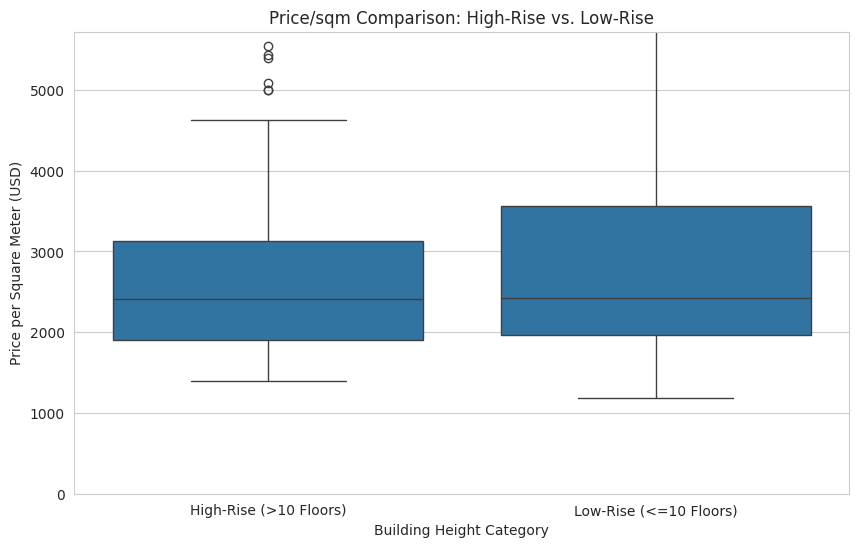

Mean Price/sqm for High-Rise (10+ floors): $2836.28
Mean Price/sqm for Low-Rise (<=10 floors): $2906.58
T-Statistic: -0.44
P-Value: 0.6630
Conclusion: We cannot reject the null hypothesis (H0). There is no significant statistical difference between the mean prices.


In [ ]:
# Create a categorical column to label High-Rise vs. Low-Rise
df_clean['Building_Type'] = np.where(df_clean['Total_Floors'] > 10, 'High-Rise (>10 Floors)', 'Low-Rise (<=10 Floors)')

# --- Visual Validation (Box Plot) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Building_Type', y='Price_per_sqm', data=df_clean)

# Adjust y-axis limit to remove extreme outliers for better visualization
y_max = df_clean['Price_per_sqm'].quantile(0.95)
plt.ylim(0, y_max)

plt.title('Price/sqm Comparison: High-Rise vs. Low-Rise')
plt.xlabel('Building Height Category')
plt.ylabel('Price per Square Meter (USD)')
plt.show()

# --- T-Test Calculation ---
high_rise = df_clean[df_clean['Total_Floors'] > 10]['Price_per_sqm'].dropna()
low_rise = df_clean[df_clean['Total_Floors'] <= 10]['Price_per_sqm'].dropna()

if len(high_rise) > 1 and len(low_rise) > 1:
    t_stat, p_value = stats.ttest_ind(high_rise, low_rise, equal_var=False)

    print(f"Mean Price/sqm for High-Rise (10+ floors): ${high_rise.mean():.2f}")
    print(f"Mean Price/sqm for Low-Rise (<=10 floors): ${low_rise.mean():.2f}")
    print(f"T-Statistic: {t_stat:.2f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: We reject the null hypothesis (H0). The mean Price/sqm for high-rise and low-rise buildings are statistically different.")
    else:
        print("Conclusion: We cannot reject the null hypothesis (H0). There is no significant statistical difference between the mean prices.")
else:
    print("Hypothesis testing is not possible: Not enough rows in one or both groups.")

# Scatter Plots (Relationships)

## Relationship between Price and Area

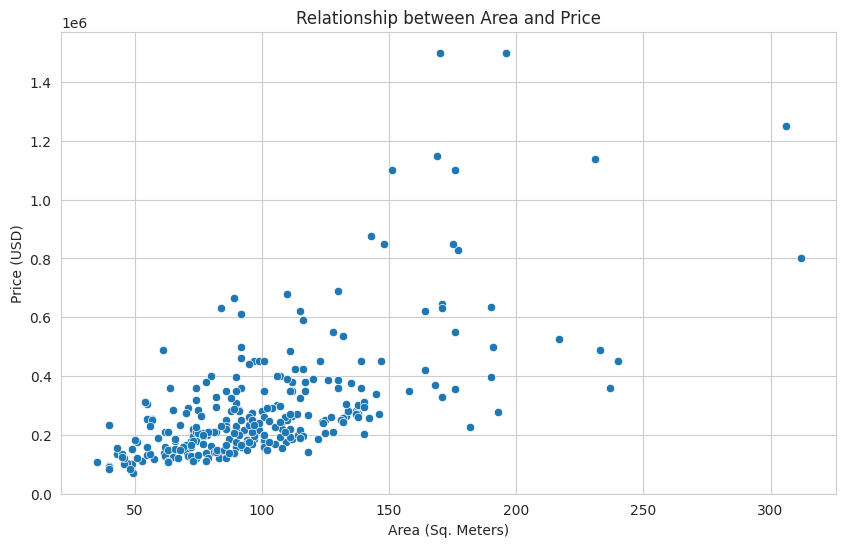

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area', y='Price', data=df_clean)
plt.title('Relationship between Area and Price')
plt.xlabel('Area (Sq. Meters)')
plt.ylabel('Price (USD)')
plt.show()

## Relationship between Price/sqm and Total Floors

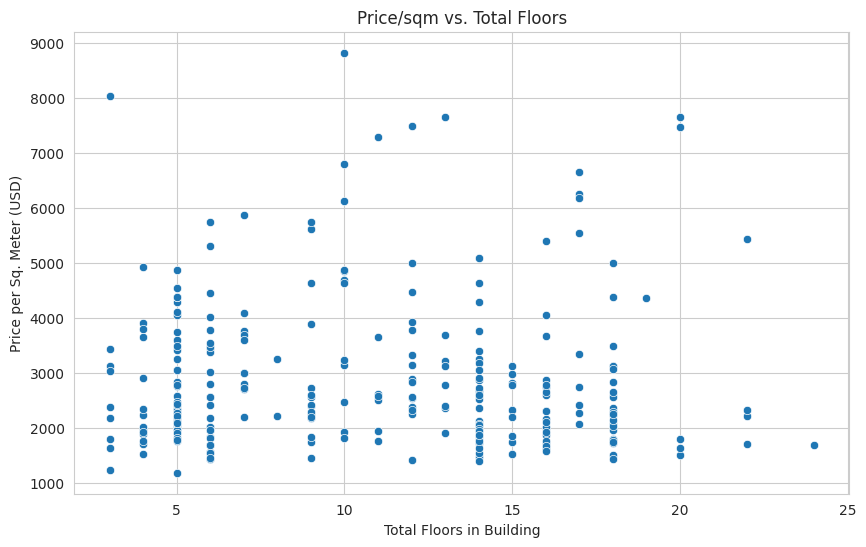

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Floors', y='Price_per_sqm', data=df_clean)
plt.title('Price/sqm vs. Total Floors')
plt.xlabel('Total Floors in Building')
plt.ylabel('Price per Sq. Meter (USD)')
plt.show()

# Bar Plots and Box Plots by Category

## Bar Plot: Number of Listings by Bedrooms

/tmp/ipython-input-2699814423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bedrooms', data=df_clean, palette='viridis')


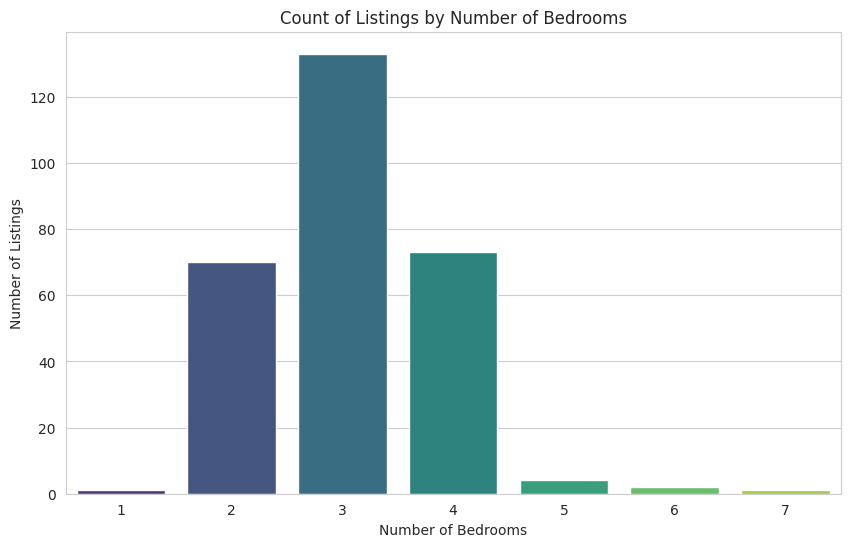

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Bedrooms', data=df_clean, palette='viridis')
plt.title('Count of Listings by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Listings')
plt.show()

## Box Plot: Price Distribution by Number of Bedrooms




/tmp/ipython-input-3147366123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bedrooms', y='Price', data=df_filtered, palette='Set2',legend = False )


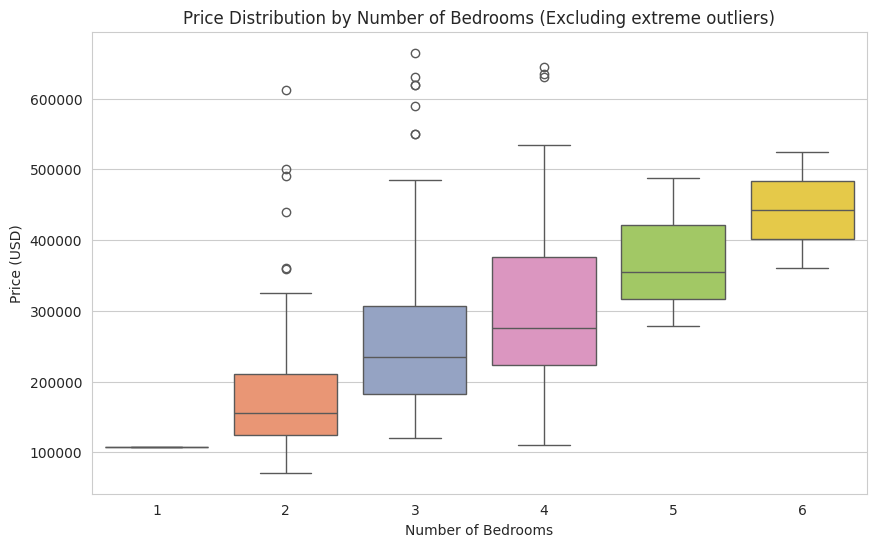

In [ ]:
plt.figure(figsize=(10, 6))
price_max = df_clean['Price'].quantile(0.95)
df_filtered = df_clean[df_clean['Price'] < price_max]

sns.boxplot(x='Bedrooms', y='Price', data=df_filtered, palette='Set2',legend = False )
plt.title('Price Distribution by Number of Bedrooms (Excluding extreme outliers)')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (USD)')
plt.show()

# *Conclusion*


---


This project provided a comprehensive understanding of the real estate dataset through data processing, exploratory analysis, and visualization. The insights gained help to identify trends, outliers, and key relationships between features, laying a strong foundation for further modeling or decision-making.